# 👩‍💻 Train an Advanced Model on Your Dataset

## 📋 Overview
This hands-on activity invites you to delve into advanced machine learning techniques by training a sophisticated model on a real-world dataset. Building on the foundation of baseline models, you will explore cutting-edge frameworks such as XGBoost, LightGBM, Transformers, or diffusion models to elevate prediction accuracy and extraction insights.

Engaging in this activity will provide you with practical experience in applying advanced models, a crucial skill for roles such as Data Scientist and ML Engineer. The hands-on practice will prepare you to effectively implement and evaluate models relevant to complex analytical tasks.

## 🎯 Learning Outcomes
By the end of this lab, you will be able to:
- Apply advanced machine learning models to complex datasets
- Evaluate model performance using appropriate metrics
- Analyze and reflect on model training challenges and results

## Task 1: Select and Prepare Your Dataset

Choose one dataset from the preselected options and conduct necessary preprocessing.

<b>Reminder:</b> A number of dataset csv files have been uploaded to this lab environment. Choose one dataset from the following options:
- Customer Churn (Telecom): `Telco-Customer-Churn.csv`
- Credit Card Fraud Detection: `creditcard.csv`
- Bike Sharing Demand Forecasting: `bikeshareday.csv`
- IMDb Sentiment Analysis (NLP): `IMDB_Dataset.csv`
- Customer Segmentation (Clustering): `marketing_campaign.csv`

### 💻 Code

In [6]:
# Load the dataset
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RandomizedSearchCV

import joblib

import warnings 
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', 10000)

In [7]:
# Load and prepare your data

# Your code here
df= pd.read_csv("creditcard.csv")

# Explore the data
print(f"Shape of Data: {df.shape}")
print("\n----- Top 5 Rows of Data ------")
display(df.head())
print("\n----- Information of Data ------")
print(df.info())
print("\n----- Summmary of Data ------")
display(df.describe(percentiles=[i/100 for i in range(0, 101) if i%5==0]).T)
print("\n------- Number of Null Values ---------")
print(df.isnull().sum())

print("Class Count:\n", df['Class'].value_counts(dropna=False))

print("Class distribution:\n", df['Class'].value_counts(dropna=False, normalize=True))

Shape of Data: (284807, 31)

----- Top 5 Rows of Data ------


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



----- Information of Data ------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807

,count,mean,std,min,0%,5%,10%,15%,20%,25%,30%,35%,40%,45%,50%,55%,60%,65%,70%,75%,80%,85%,90%,95%,100%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,0.000000,25297.600000,35027.000000,41216.900000,47694.200000,54201.500000,60776.000000,67232.200000,73261.400000,78622.000000,84692.000000,108574.300000,120396.000000,126528.000000,132929.000000,139320.500000,145247.800000,151328.100000,157640.400000,164143.400000,172792.000000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-56.407510,-2.899147,-1.893272,-1.424545,-1.134663,-0.920373,-0.747294,-0.586700,-0.426756,-0.261842,0.018109,0.570896,1.035107,1.152127,1.224825,1.315642,1.694936,1.924286,2.015409,2.081223,2.454930,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-72.715728,-1.971975,-1.359862,-1.039394,-0.790814,-0.598550,-0.436393,-0.288185,-0.153805,-0.044536,0.065486,0.178647,0.302738,0.459688,0.636845,0.803724,0.957314,1.110220,1.326635,1.808585,22.057729,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-48.325589,-2.389740,-1.802587,-1.483557,-1.169050,-0.890365,-0.616806,-0.397156,-0.199061,0.000025,0.179846,0.331263,0.497040,0.664793,0.843541,1.027196,1.215700,1.417794,1.676173,2.062635,9.382558,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-5.683171,-2.195683,-1.656329,-1.356979,-1.066085,-0.848640,-0.696226,-0.560589,-0.394161,-0.196881,-0.019847,0.142120,0.284856,0.417078,0.558866,0.743341,0.986188,1.213360,1.482807,2.566501,16.875344,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-113.743307,-1.702021,-1.302171,-1.053683,-0.859581,-0.691597,-0.544455,-0.413004,-0.290112,-0.169525,-0.054336,0.064423,0.186625,0.318202,0.457029,0.611926,0.802235,1.042777,1.407893,2.098960,34.801666,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-26.160506,-1.406757,-1.167450,-1.015736,-0.878153,-0.768296,-0.667845,-0.572757,-0.479473,-0.374254,-0.274187,-0.168713,-0.048200,0.077642,0.223245,0.398565,0.628995,0.949038,1.509365,3.160382,73.301626,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-43.557242,-1.434423,-1.078148,-0.846610,-0.683316,-0.554076,-0.426020,-0.286806,-0.159341,-0.051778,0.040103,0.122825,0.213512,0.319154,0.446175,0.570436,0.698332,0.854903,1.039387,1.407632,120.589494,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-73.216718,-0.842147,-0.458945,-0.341845,-0.266300,-0.208630,-0.158158,-0.110961,-0.066057,-0.022503,0.022358,0.069873,0.120489,0.177424,0.243400,0.327346,0.435529,0.578494,0.769381,1.049984,20.007208,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-13.434066,-1.758426,-1.294047,-1.016505,-0.808875,-0.643098,-0.502165,-0.371384,-0.257730,-0.151438,-0.051429,0.054936,0.176169,0.311033,0.445942,0.597139,0.791583,1.020710,1.301671,1.780783,15.594995,15.594995



------- Number of Null Values ---------
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Class Count:
 Class
0    284315
1       492
Name: count, dtype: int64
Class distribution:
 Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [8]:
X = df.drop(columns=['Class'])  # Features
y = df['Class']                 # Target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

### 🔍 Practice
- Select a dataset: Choose from the available datasets, such as Customer Churn or IMDb Sentiment Analysis.
- Preprocess data: Perform essential cleaning, encoding, and scaling. Apply feature engineering as discussed in previous modules.

### ✅ Success Checklist
- Data is cleaned and free of missing values.
- Features are appropriately encoded.
- Dataset distribution is visualized, showing key patterns.

## Task 2: Train an Advanced Model 
Implement your chosen advanced model considering dataset suitability and training objectives.

### 💻 Code

In [11]:
# Train your model

# Logistic Regression

log_reg = LogisticRegression(max_iter=1000, random_state=42)

log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:,1]

print("Logistic Regression ROC-AUC Score:", roc_auc_score(y_test, y_prob))

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression ROC-AUC Score: 0.9752930012747925

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.58      0.70        98

    accuracy                           1.00     56962
   macro avg       0.93      0.79      0.85     56962
weighted avg       1.00      1.00      1.00     56962



In [12]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("Random Forest ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest ROC-AUC Score: 0.9478060076028161

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.99      0.76      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99      0.88      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [13]:
# XGBoost

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print("XGBoost ROC-AUC Score:", roc_auc_score(y_test, y_prob_xgb))

print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost ROC-AUC Score: 0.940590259035522

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.81      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [14]:
# Hyperpramter Tuning for Xgboost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Define parameter grid
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.5],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 1.5, 2]
}

random_search = RandomizedSearchCV(
    xgb, param_distributions=param_dist,
    n_iter=30, scoring='roc_auc', cv=3, verbose=2, n_jobs=-1, random_state=42
)


random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters: {'subsample': 0.6, 'reg_lambda': 1.5, 'reg_alpha': 0.01, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 1.0}
Best Score: 0.9841816361688639


In [15]:
# Train with Best XGBoost Parameters

best_xgb = XGBClassifier(
    subsample=0.6,
    reg_lambda=1.5,
    reg_alpha=0.01,
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    gamma=0.1,
    colsample_bytree=1.0,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

best_xgb.fit(X_train, y_train)


y_pred_best_xgb = best_xgb.predict(X_test)
y_prob_best_xgb = best_xgb.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob_best_xgb)
print("XGBoost (Tuned) ROC-AUC Score:", roc_auc)

print("XGBoost (Tuned) Classification Report:\n")
print(classification_report(y_test, y_pred_best_xgb))

XGBoost (Tuned) ROC-AUC Score: 0.9833076484673781
XGBoost (Tuned) Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.99      0.79      0.88        98

    accuracy                           1.00     56962
   macro avg       0.99      0.89      0.94     56962
weighted avg       1.00      1.00      1.00     56962



### 🔍 Practice
1. Choose and implement a suitable advanced model like XGBoost or a Transformer.
2. Train the model with fine-tuned hyperparameters for optimal performance.

### ✅ Success Checklist
- Model is implemented without errors.
- Training completes with reasonable time and resource use.

## Task 3: Evaluate and Reflect 
Assess the model's performance and reflect on the training process.

### 💻 Code

                 Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
0  Logistic Regression  0.999122   0.863636  0.581633  0.695122  0.975293
1        Random Forest  0.999561   0.986667  0.755102  0.855491  0.947806
2              XGBoost  0.999579   0.940476  0.806122  0.868132  0.940590
3        XGBoost Tuned  0.999614   0.987179  0.785714  0.875000  0.983308


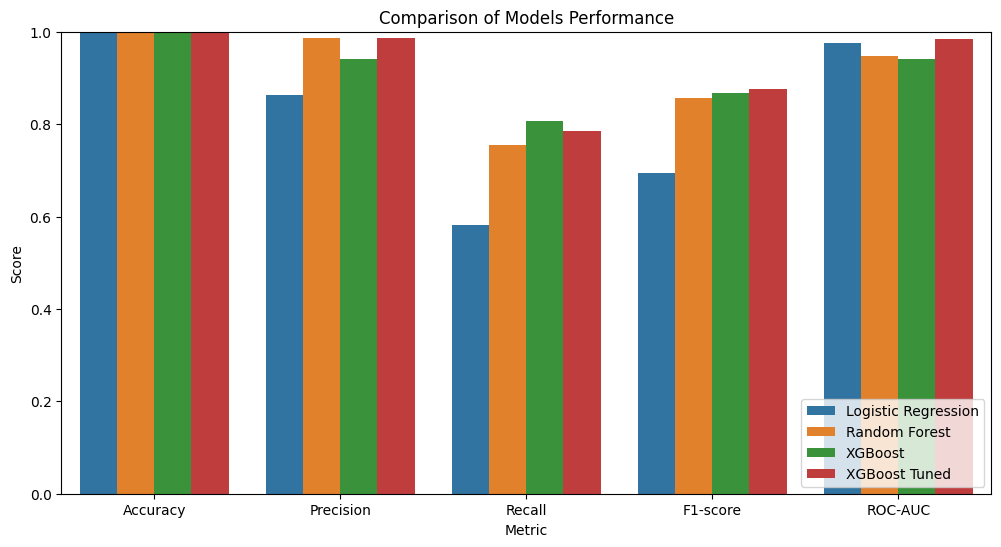

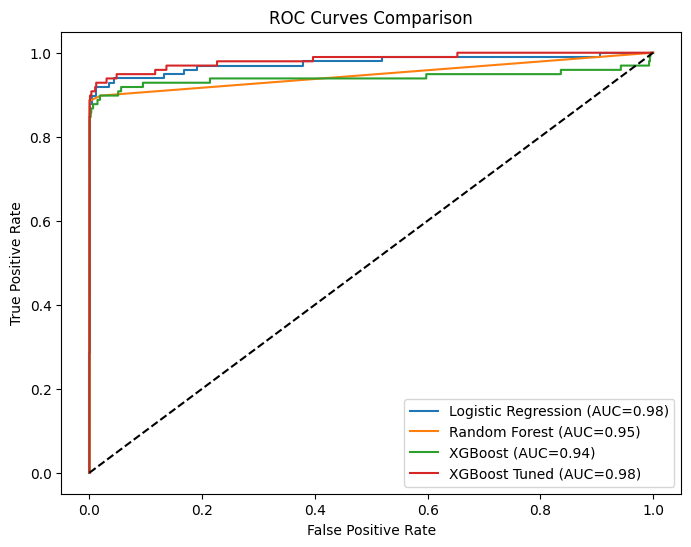

In [16]:
# Predict and evaluate
# Compare All Models

models = {
    "Logistic Regression": (y_test, y_pred, y_prob),
    "Random Forest": (y_test, y_pred_rf, y_prob_rf),
    "XGBoost": (y_test, y_pred_xgb, y_prob_xgb),
    "XGBoost Tuned": (y_test, y_pred_best_xgb, y_prob_best_xgb)
}

results = []

for name, (yt, yp, ypr) in models.items():
    report = classification_report(yt, yp, output_dict=True)
    auc = roc_auc_score(yt, ypr)
    acc = accuracy_score(yt, yp)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1-score": report["1"]["f1-score"],
        "ROC-AUC": auc
    })

df_results = pd.DataFrame(results)
print(df_results)

metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

plt.figure(figsize=(12, 6))
df_melted = df_results.melt(id_vars="Model", value_vars=metrics, 
                            var_name="Metric", value_name="Score")
sns.barplot(data=df_melted, x="Metric", y="Score", hue="Model")
plt.title("Comparison of Models Performance")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

# -------------------------------
# 3 ROC Curves
# -------------------------------
plt.figure(figsize=(8, 6))

for name, (yt, yp, ypr) in models.items():
    fpr, tpr, _ = roc_curve(yt, ypr)
    auc = roc_auc_score(yt, ypr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.show()

In [17]:
joblib.dump(best_xgb, "best_model.pkl")
print("Best model saved as best_model.pkl")

Best model saved as best_model.pkl


# Deployment

In [5]:
!pip install --q gradio


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [19]:
X_train[0]

array([ 1.02211246,  0.99813578, -0.23059493, -0.20775754,  0.23318268,
       -0.36904644, -0.06469975, -0.50762449,  0.03013664,  0.95988654,
       -0.02795739,  0.61231399,  1.69285059,  1.26175537, -0.2642062 ,
       -0.36238366,  0.35064408, -1.09596692,  0.77748202,  0.20636189,
       -0.16264904,  0.32428871,  1.3343042 ,  0.08520655, -0.46000718,
       -0.0863251 , -0.4495408 ,  0.11190459, -0.14282722, -0.31328851])

In [22]:
import gradio as gr

model = joblib.load("best_model.pkl")

feature_columns = ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9',
                   'V10','V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18',
                   'V19', 'V20','V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27',
                   'V28', 'Amount']

def predict_model(*features):
    data = pd.DataFrame([features], columns=feature_columns)
    prediction = model.predict(data)[0]
    prob = model.predict_proba(data)[0][1]
    return int(prediction), float(prob)  

inputs = [gr.Number(label=col) for col in feature_columns]

iface = gr.Interface(
    fn=predict_model,
    inputs=inputs,
    outputs=[gr.Label(label="Prediction"), gr.Number(label="Probability of Fraud")],
    title="Fraud Detection Model",
    description="Enter transaction features to get prediction from the best model."
)

iface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7861

Could not create share link. Missing file: /root/.cache/huggingface/gradio/frpc/frpc_linux_amd64_v0.3. 

Please check your internet connection. This can happen if your antivirus software blocks the download of this file. You can install manually by following these steps: 

1. Download this file: https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_linux_amd64
2. Rename the downloaded file to: frpc_linux_amd64_v0.3
3. Move the file to this location: /root/.cache/huggingface/gradio/frpc


### 🔍 Practice
1. Evaluate model performance with chosen metrics (e.g., accuracy, precision).
2. Reflect on improvements from baseline models and note any training challenges or insights.

### ✅ Success Checklist
- Evaluation metrics show improvement over baseline.
- Recognized patterns in data or model performance are documented.

## ❗ Common Mistakes to Avoid
- Overfitting due to an overly complex model or inadequate regularization
- Insufficient data preprocessing leads to inaccurate predictions
- Choosing a model unsuitable for the dataset's characteristics

## 📚 Exemplar Solution
Below is an exemplar solution for the given tasks. Note that this is a simplified high level exemplar solution, and may not be exact depending on the dataset you are choosing to work with.

<details>

<summary><strong>Click HERE to see a reference solution</strong></summary>    
    
```python
# TASK 1
# Example for importing and inspecting data
import pandas as pd

# Load the dataset

data = pd.read_csv('your_dataset.csv')

# Initial data inspection
print(data.head())

# TASK 2
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Note: Preprocessing steps may be required and will be unique depending on the dataset and model you are using
# In this case we are simplifying our example by only looking at numeric variables

# Convert target to numeric
data['target'] = data['target'].map({'Yes': 1, 'No': 0})

# Ensure TotalCharges is numeric
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data = data.dropna(subset=['TotalCharges'])

# Keep only numeric columns
numeric_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
X = data[numeric_cols]
y = data['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert to DMatrix (no categorical columns, so no extra params)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Set parameters
params = {
    'objective': 'binary:logistic',
    'max_depth': 6,
    'eta': 0.3,
    'eval_metric': 'logloss'
}

# Train model
bst = xgb.train(params, dtrain, num_boost_round=100)

# TASK 3
from sklearn.metrics import accuracy_score

# Predict and evaluate
dtest = xgb.DMatrix(X_test, enable_categorical=True)
preds = bst.predict(dtest)
predictions = [round(value) for value in preds]
accuracy = accuracy_score(y_test, predictions)
print(f'XGBoost Model Accuracy: {accuracy}')
```    

## 🚀 Next Steps
In practice, integrating advanced model results can inform business strategies or innovations. Reflect on how model choices affect outcomes and consider further model tuning or exploration of ensemble methods introduced in subsequent lessons.